In [41]:
%pip install torch

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [74]:
import os
import numpy as np
import sys
import pandas as pd
import torch.cuda
from openpyxl import load_workbook, Workbook

notebook_dir = os.path.abspath('')

root_dir = os.path.abspath(os.path.join(notebook_dir, '..', '..'))

if root_dir not in sys.path:
    sys.path.append(root_dir)

from stable_baselines3 import SAC
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.results_plotter import plot_results
from stable_baselines3.common import results_plotter

from aml_project.environments.lettuce_greenhouse import LettuceGreenhouse
from aml_project.common.plot_gh_variables import create_trajectory_figure, plot_trajectory

In [75]:


# Define the exact coefficients from Morcego et al. (2023)
# reward_coefs = [c_r1 (growth), c_r_co2_2 (CO2 in-bounds)]
custom_reward_coefs = np.array([15.0, 0.005])

# penalty_coefs = [c_r_u1 (CO2), c_r_u2 (Vent), c_r_u3 (Heat), c_r_co2_1 (CO2 bounds), c_r_T1 (Temp low), c_r_T2 (Temp high), c_r_RH (RH), c_r_co2_vent (CO2+vent), c_coact (heat+vent action)]
custom_penalty_coefs = np.array([0.002, 0.02, 0.01, 15.0, 3.0, 1.5, 0.2, 5.0, 0.0])

weather_file = root_dir + r"\aml_project\environments\weather\outdoorWeatherWurGlas2014.mat"

base_env = LettuceGreenhouse(
    weather_data_dir=weather_file, 
    reward_coefs=custom_reward_coefs, 
    penalty_coefs=custom_penalty_coefs,
    n_days=5
)
monitor = Monitor(env, log_dir)

In [ ]:

# Initialize the Soft Actor-Critic model
device = "cuda" if torch.cuda.is_available() else "cpu"
model = SAC("MlpPolicy", train_env, verbose=1, learning_rate=1e-3, batch_size=64, device='cpu')
model.learn(total_timesteps=10000) 
model.save("sac_lettuce_greenhouse")

#plot accumulated reward per episode
plt.plot(model.ep_info_buffer)
plt.xlabel('Episode')
plt.ylabel('Reward')

Using cpu device


In [87]:
import os
monitor_path = os.path.join(log_dir, "monitor.csv")
print("Training episode length (timesteps):", env.N)
print("Monitor log path:", monitor_path)
if os.path.exists(monitor_path):
    with open(monitor_path, "r") as monitor_file:
        lines = monitor_file.readlines()
    print("Monitor file rows:", len(lines) - 1)
    print("Monitor file content:\n", "".join(lines[-10:]))
else:
    print("Monitor file not found.")

Training episode length (timesteps): 480
Monitor log path: tmp\monitor.csv
Monitor file rows: 83
Monitor file content:
 -33.49287,480,453.788676
-34.179075,480,459.193298
-24.049795,480,465.766144
-22.548181,480,471.64068
-2.758846,480,476.905848
-4.267171,480,481.872999
2.059276,480,486.194899
-0.847751,480,492.053491
-9.964397,480,498.16142
-0.289531,480,503.425757



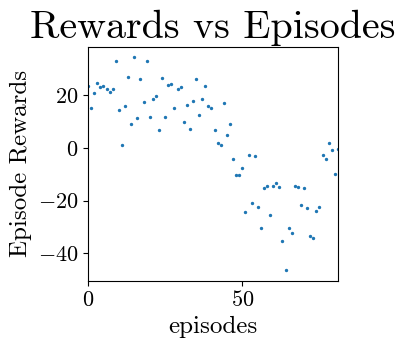

In [88]:
import matplotlib.pyplot as plt
from stable_baselines3.common import results_plotter

# Plot by timesteps (shows sample efficiency)
# plot_results([log_dir], None, results_plotter.X_TIMESTEPS, "Rewards vs Timesteps")
# By episodes:]


plot_results([log_dir], None, results_plotter.X_EPISODES, "Rewards vs Episodes",figsize=(4,4))
# plot_results([log_dir], None, results_plotter.X_WALLTIME, "Rewards vs Time")
plt.show()


In [89]:
print("Starting evaluation...")

# Reset the wrapped environment
obs = train_env.reset() 

N_steps = base_env.N
ny = base_env.ny
action_dim = base_env.action_space.shape[0]

y = np.zeros((N_steps + 1, ny))
u = np.zeros((N_steps, action_dim))
rewards = np.zeros((N_steps, 1))

# 2. unnormalized initial observation from the wrapper
y[0] = train_env.get_original_obs()[0][:ny]
base_env.prev_action = np.zeros(action_dim)

k = 0
done = False 

while not done and k < N_steps:
    action, _states = model.predict(obs, deterministic=True)
    
    # Step the environment
    obs, reward, dones, infos = train_env.step(action)
    done = dones[0]

    u[k] = base_env.prev_action
    
    # unnormalized physical observation for this step
    unnormalized_obs = train_env.get_original_obs()
    y[k+1] = unnormalized_obs[0][:ny] 

    rewards[k] += reward[0]
    k += 1

y = y[:k]
d = weather2ppmrh(base_env.d[:k])
u = u[:k]
r = rewards[:k]

print(f"Evaluation complete. Total Reward: {np.sum(r):.2f}")

Starting evaluation...
Evaluation complete. Total Reward: -17992.60


Plotting results...


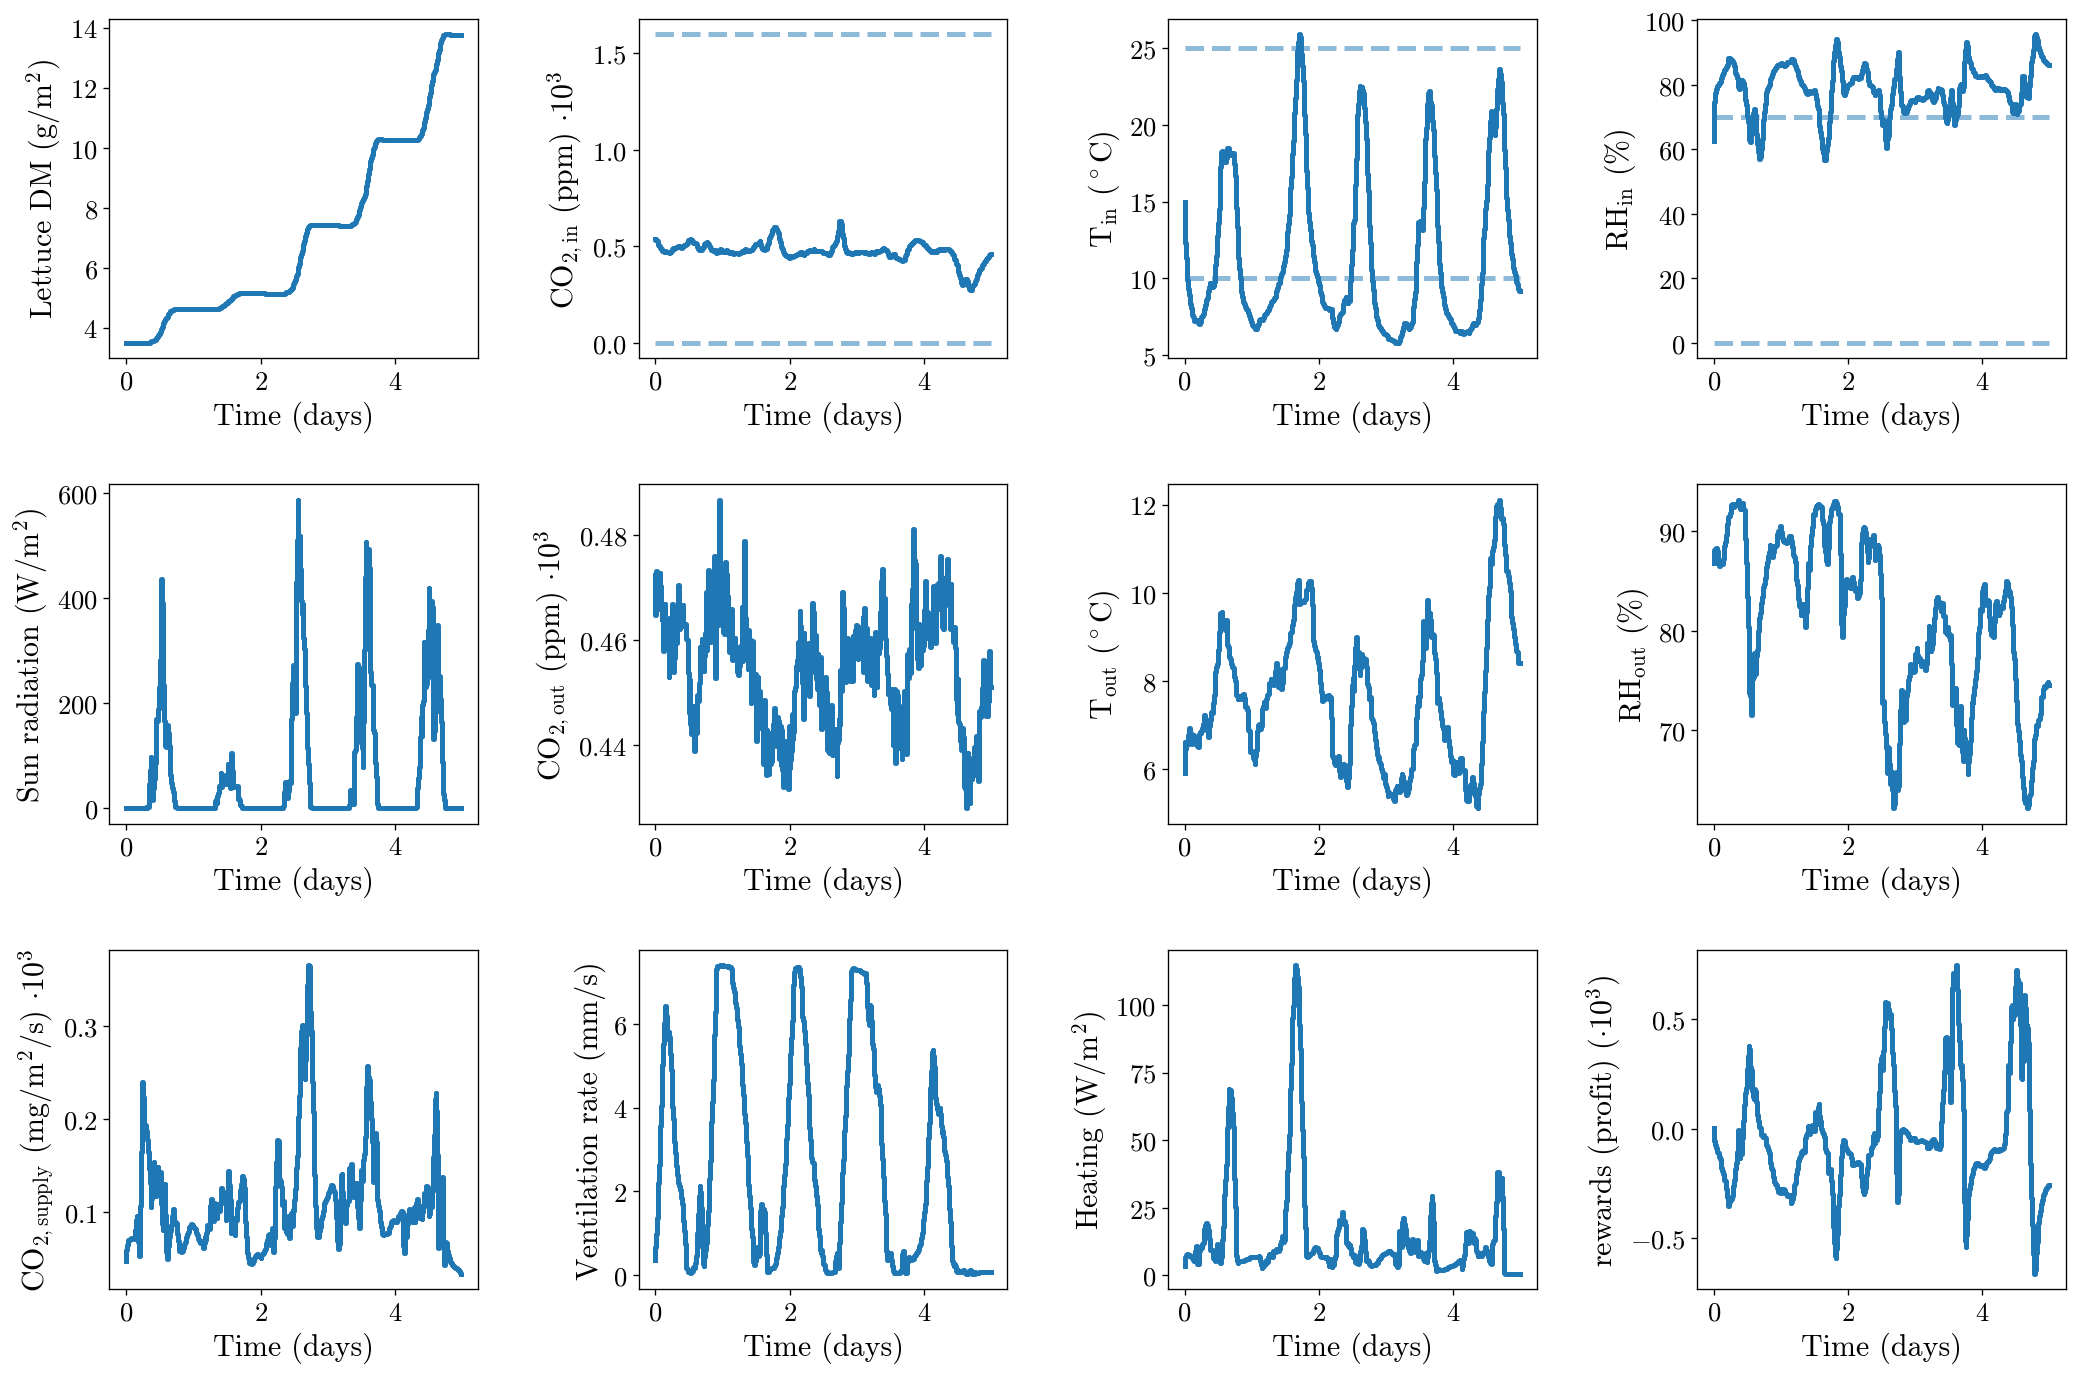

In [90]:
print("Plotting results...")

nvars = 12
n_per_day = int((24 * 3600) / base_env.h) 
label = 'Trained SAC policy'
trajectory = np.concatenate((y, d, u, r), axis=1)
fig, axes = create_trajectory_figure(nvars, env.L, env.h, env.c, env.obs_low, env.obs_high)
fig, axes = plot_trajectory(fig, axes, trajectory, env.L, env.h, env.c, 0, env.n_days, n_per_day, label)

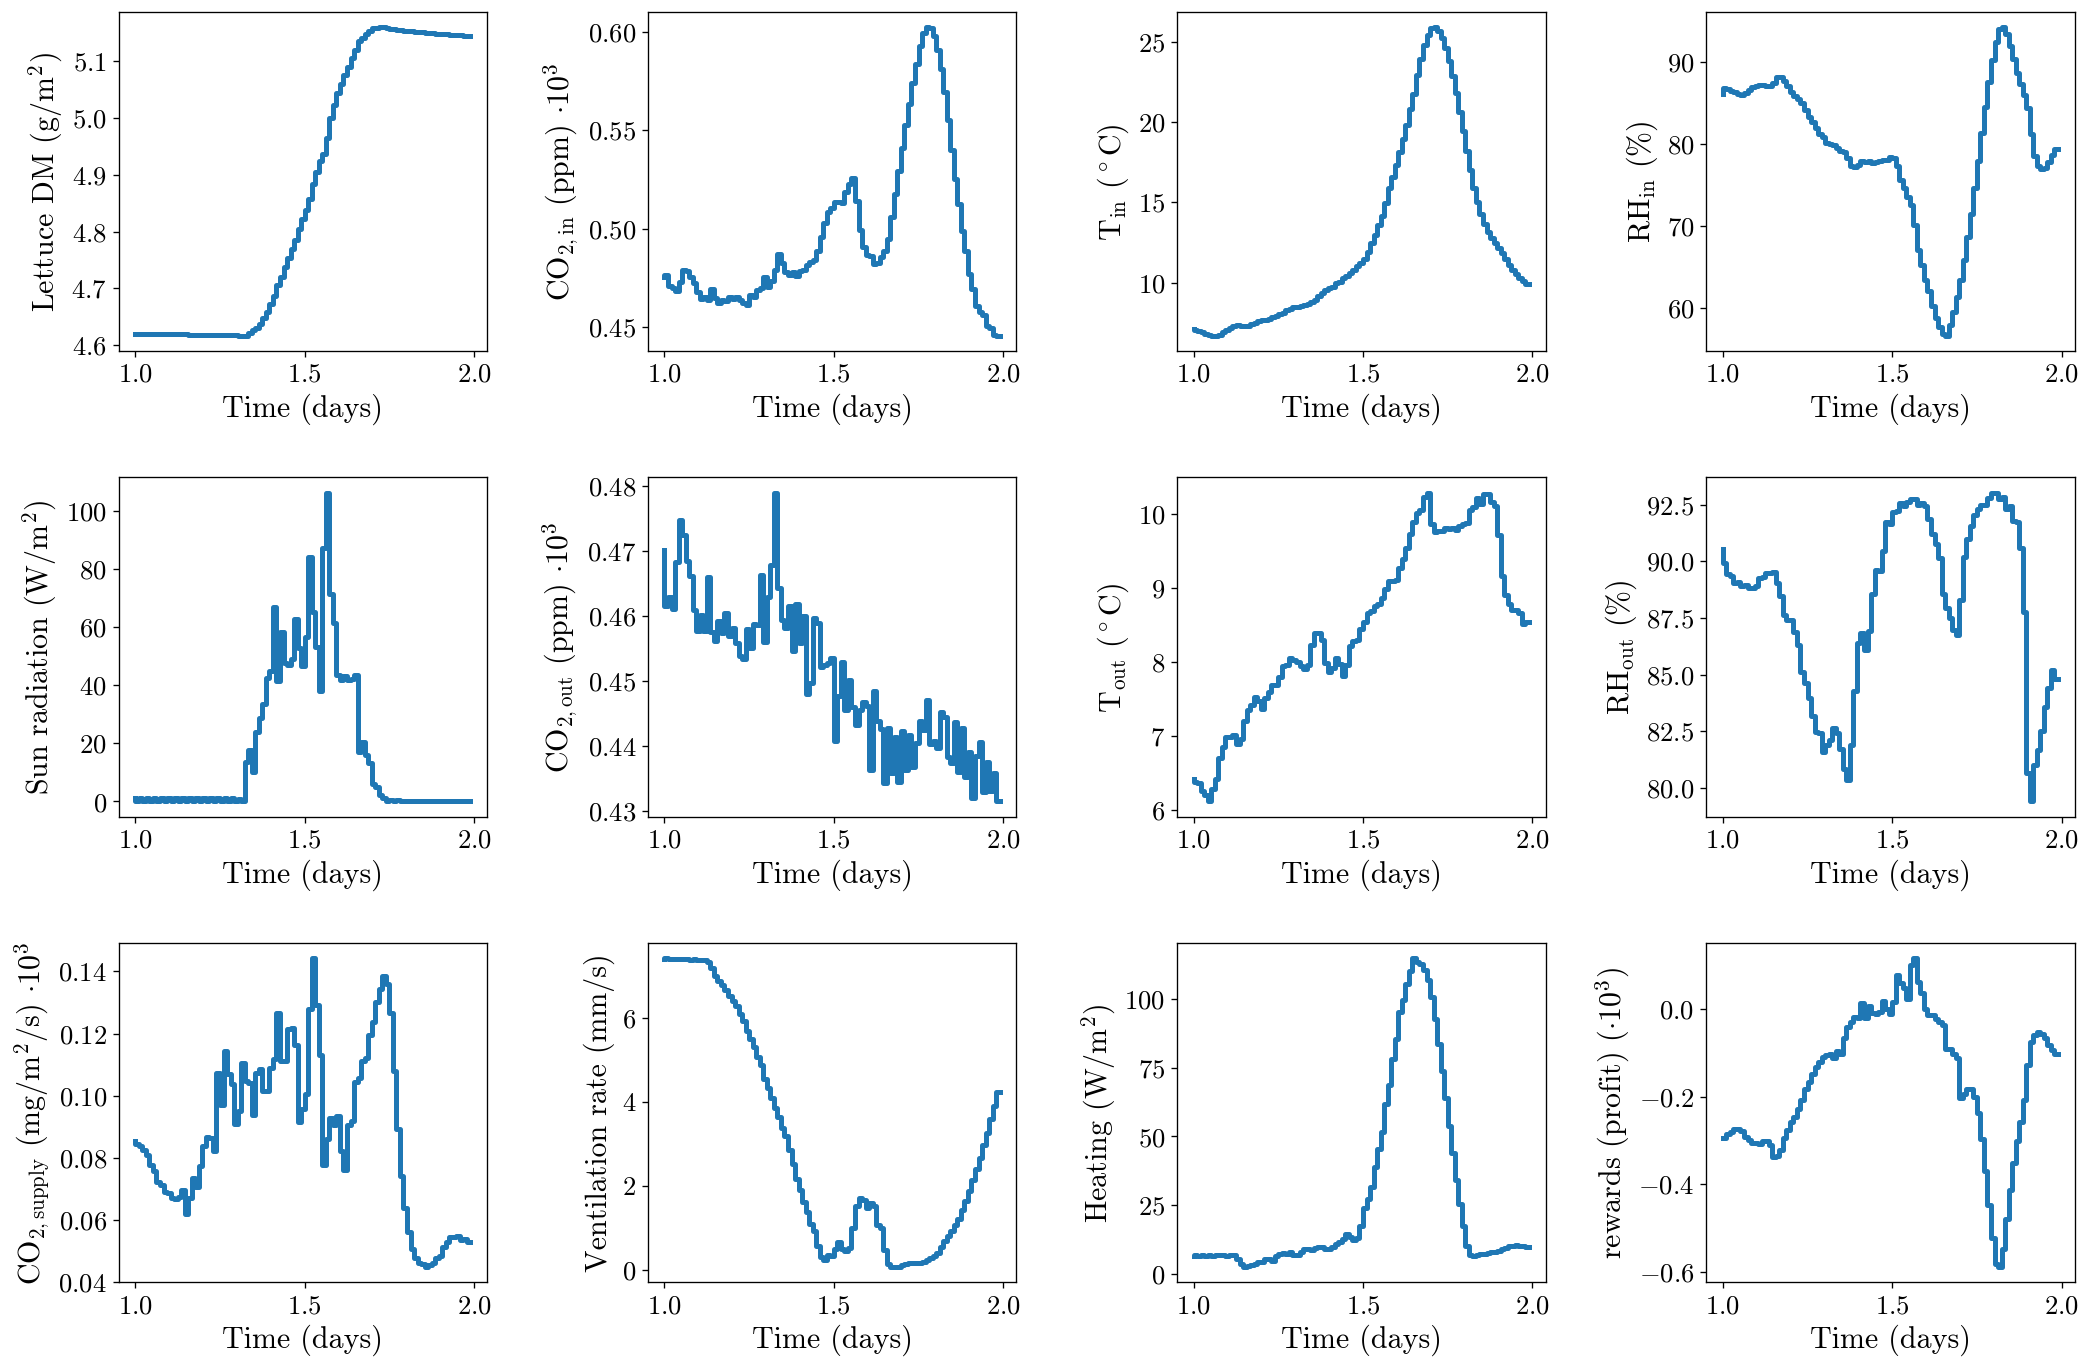

In [91]:
# Change 'env' to 'base_env' so the plotting function can see your greenhouse dimensions
fig, axes = create_trajectory_figure(
    nvars, 
    base_env.L, 
    base_env.h, 
    base_env.c, 
    base_env.obs_low,  # It's better to pass your actual bounds here instead of None!
    base_env.obs_high  # (Or leave as None, None if your function specifically handles it)
)

fig, axes = plot_trajectory(
    fig, 
    axes, 
    trajectory, 
    base_env.L, 
    base_env.h, 
    base_env.c, 
    20,           # Start day (make sure this matches your intended slice!)
    2,            # Number of days to plot
    n_per_day, 
    label
)

In [ ]:
def run_zero_input_baseline(env):
    # First heuristic where we hold all inputs at 0 (minimum)
    obs, info = env.reset()
    terminated = False
    done = False
    
    # Action space is scaled between -1 and 1. -1 corresponds to 0 physical input.
    zero_action = np.array([-1.0, -1.0, -1.0], dtype=np.float32) 
    
    while not terminated and not done:
        obs, reward, terminated, truncated, info = env.step(zero_action)
        
    return info['profit'].sum(), info


def run_heuristic_baseline(env):
    # Second heuristic where we dose CO2 if below 850 ppm, heat if below 16C, and ventilate if above 19.5C
    obs, info = env.reset()
    terminated = False
    done = False
    
    while not terminated and not done:
        # obs[:4] corresponds to greenhouse measurements: [dry_weight, co2_ppm, temp_c, rh]
        co2_ppm = obs[1]
        temp_c = obs[2]
        
        # CO2 Dosing 
        co2_act = 0.2 if co2_ppm < 850 else -1.0
        
       # Temperature 
        if temp_c < 16.0:
            heat_act = 0.5  # Turn on heating
            vent_act = -1.0 # Close vents to trap heat
        elif temp_c > 19.5:
            heat_act = -1.0 # Turn off heating
            vent_act = 0.3  # Open vents to cool down
        else:
            heat_act = -1.0 # Optimal band: do nothing
            vent_act = -1.0
            
        action = np.array([co2_act, vent_act, heat_act], dtype=np.float32)
        obs, reward, terminated, truncated, info = env.step(action)
        
    return info['profit'].sum(), info

In [83]:
# Actual evaluation of the trained SAC agent
sac_total_profit = info['profit'].sum()

zero_profit, zero_info = run_zero_input_baseline(env)
heuristic_profit, heuristic_info = run_heuristic_baseline(env)

print(f"--- Cumulative Profit Comparison ---")
print(f"Zero-Input Baseline Profit : {zero_profit:.2f}")
print(f"Heuristic Baseline Profit  : {heuristic_profit:.2f}")
print(f"Trained SAC Agent Profit   : {sac_total_profit:.2f}")

co2_ppm: 0.5343741774559021, r_co2: -0.035278538801114305
co2_ppm: 0.5310779809951782, r_co2: -0.036159526152814876
co2_ppm: 0.5285651087760925, r_co2: -0.03683845008686725
co2_ppm: 0.5262120962142944, r_co2: -0.037479908129685394
co2_ppm: 0.5241629481315613, r_co2: -0.03804303959173589
co2_ppm: 0.5222312808036804, r_co2: -0.038577730681981934
co2_ppm: 0.5207155346870422, r_co2: -0.03899990628257237
co2_ppm: 0.5193307399749756, r_co2: -0.03938761676149739
co2_ppm: 0.5181077718734741, r_co2: -0.039731614139068665
co2_ppm: 0.5168157815933228, r_co2: -0.040096650777300354
co2_ppm: 0.5155899524688721, r_co2: -0.040444537568329234
co2_ppm: 0.5144174695014954, r_co2: -0.04077869086296468
co2_ppm: 0.5133045315742493, r_co2: -0.04109714580793033
co2_ppm: 0.5123039484024048, r_co2: -0.041384509052423094
co2_ppm: 0.5114057660102844, r_co2: -0.041643315946055366
co2_ppm: 0.5103914737701416, r_co2: -0.0419365492325153
co2_ppm: 0.5094706416130066, r_co2: -0.04220365404237904
co2_ppm: 0.508533895015